# Atividade I – Cálculo Numérico
## Erros numéricos em aplicações simples de biofluidodinâmica

**Integrantes:** _(preencher nomes)_
**Divisão das tarefas:** _(preencher: quem fez Parte A, B, C, D, E, GIF)_

Este notebook calcula erros absoluto, relativo e percentual, compara
truncamento e arredondamento, e observa a propagação desses erros em
cálculos de pressão arterial e de vazão (Hagen–Poiseuille), incluindo um
modelo didático de nanocateter.

In [1]:
import math
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import imageio.v2 as imageio
from IPython.display import Image, display

plt.rcParams["figure.dpi"] = 100
np.set_printoptions(suppress=True)

## Funções comentadas de truncamento e cálculo dos erros

`truncar(x, n)` elimina os algarismos após a n-ésima casa decimal, sem
arredondar, usando `math.trunc(10**n * x) / 10**n`. `arredondar(x, n)`
apenas usa o `round` nativo do Python (que já considera o primeiro
algarismo descartado). `calcular_erros` devolve os três tipos de erro
pedidos no enunciado: absoluto, relativo e percentual.

In [2]:
def truncar(x: float, n: int) -> float:
    """Trunca x para n casas decimais (descarta, não arredonda)."""
    fator = 10 ** n
    return math.trunc(x * fator) / fator


def arredondar(x: float, n: int) -> float:
    """Arredonda x para n casas decimais."""
    return round(x, n)


def calcular_erros(x_ref: float, x_aprox: float):
    """Retorna (erro absoluto, erro relativo, erro percentual) de x_aprox
    em relação ao valor de referência x_ref."""
    ea = abs(x_ref - x_aprox)
    er = ea / abs(x_ref) if x_ref != 0 else float("nan")
    ep = 100 * er
    return ea, er, ep

# Parte A – Truncamento e arredondamento

In [3]:
valores_A = {"x1": 3.14159265, "x2": 98.76543, "x3": 0.00498765}
casas = [0, 1, 2, 3, 4]

linhas_A = []
for nome, x in valores_A.items():
    for n in casas:
        xt = truncar(x, n)
        xr = arredondar(x, n)
        ea_t, er_t, ep_t = calcular_erros(x, xt)
        ea_r, er_r, ep_r = calcular_erros(x, xr)
        linhas_A.append(
            {
                "variavel": nome,
                "x_referencia": x,
                "n_casas": n,
                "truncado": xt,
                "arredondado": xr,
                "Ea_trunc": ea_t,
                "Er_trunc": er_t,
                "E%_trunc": ep_t,
                "Ea_arred": ea_r,
                "Er_arred": er_r,
                "E%_arred": ep_r,
            }
        )

df_A = pd.DataFrame(linhas_A)
pd.set_option("display.float_format", lambda v: f"{v:.8f}")
display(df_A)
df_A.to_csv("parteA_tabela.csv", index=False)

,variavel,x_referencia,n_casas,truncado,arredondado,Ea_trunc,Er_trunc,E%_trunc,Ea_arred,Er_arred,E%_arred
0,x1,3.14159265,0,3.00000000,3.00000000,0.14159265,0.04507034,4.50703404,0.14159265,0.04507034,4.50703404
1,x1,3.14159265,1,3.10000000,3.10000000,0.04159265,0.01323935,1.32393517,0.04159265,0.01323935,1.32393517
2,x1,3.14159265,2,3.14000000,3.14000000,0.00159265,0.00050696,0.05069562,0.00159265,0.00050696,0.05069562
3,x1,3.14159265,3,3.14100000,3.14200000,0.00059265,0.00018865,0.01886464,0.00040735,0.00012966,0.01296635
4,x1,3.14159265,4,3.14150000,3.14160000,0.00009265,0.00002949,0.00294914,0.00000735,0.00000234,0.00023396
5,x2,98.76543000,0,98.00000000,99.00000000,0.76543000,0.00774998,0.77499789,0.23457000,0.00237502,0.23750213
6,x2,98.76543000,1,98.70000000,98.80000000,0.06543000,0.00066248,0.06624788,0.03457000,0.00035002,0.03500213
7,x2,98.76543000,2,98.76000000,98.77000000,0.00543000,0.00005498,0.00549788,0.00457000,0.00004627,0.00462713
8,x2,98.76543000,3,98.76500000,98.76500000,0.00043000,0.00000435,0.00043538,0.00043000,0.00000435,0.00043538
9,x2,98.76543000,4,98.76540000,98.76540000,0.00003000,0.00000030,0.00003038,0.00003000,0.00000030,0.00003038


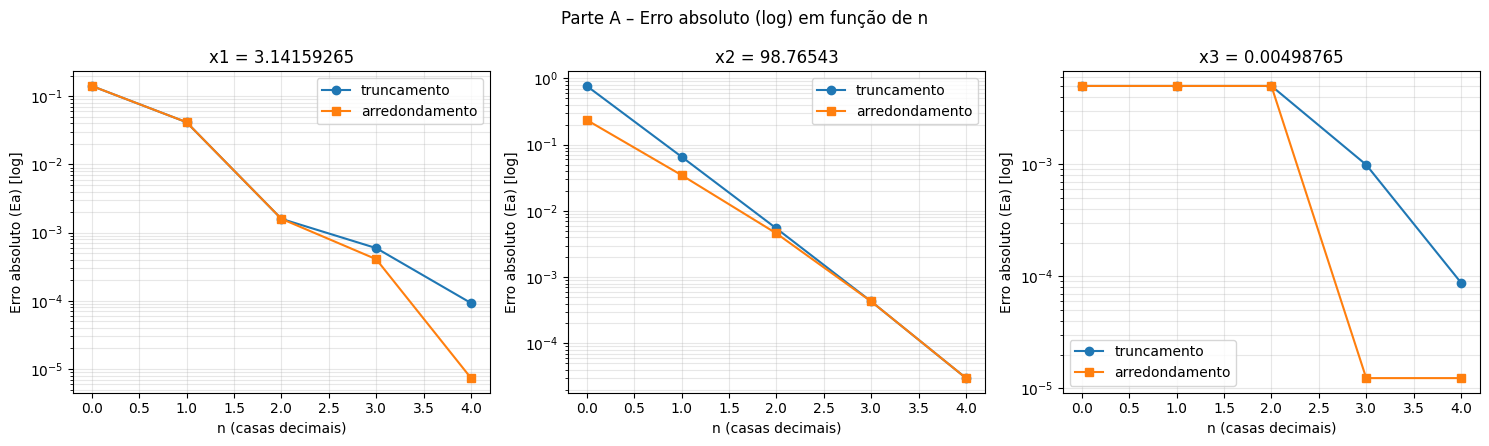

In [4]:
# Gráfico em escala log de Ea em função de n (um subplot por variável)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
piso = 1e-16  # piso numérico só para permitir plotar Ea=0 em escala log
for ax, (nome, x) in zip(axs, valores_A.items()):
    sub = df_A[df_A["variavel"] == nome]
    ea_t = np.where(sub["Ea_trunc"] == 0, piso, sub["Ea_trunc"])
    ea_r = np.where(sub["Ea_arred"] == 0, piso, sub["Ea_arred"])
    ax.semilogy(sub["n_casas"], ea_t, "o-", label="truncamento")
    ax.semilogy(sub["n_casas"], ea_r, "s-", label="arredondamento")
    ax.set_title(f"{nome} = {x}")
    ax.set_xlabel("n (casas decimais)")
    ax.set_ylabel("Erro absoluto (Ea) [log]")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
fig.suptitle("Parte A – Erro absoluto (log) em função de n")
fig.tight_layout()
fig.savefig("parteA_erros.png", dpi=150)
plt.show()

**Pergunta:** arredondar sempre gera erro menor ou igual ao truncamento?

Observando `df_A`, para cada `n` o erro do arredondamento (`Ea_arred`) é
sempre menor ou igual ao erro do truncamento (`Ea_trunc`). Isso é
esperado: o truncamento sempre "acerta por falta" (para números
positivos), descartando todo o resto do número, enquanto o
arredondamento escolhe entre a aproximação por falta e por excesso,
aquela mais próxima do valor real — no pior caso ele empata com o
truncamento (quando o algarismo descartado é 0..4, ambos coincidem), mas
nunca é pior. _(edite este parágrafo com os números específicos obtidos)_

# Parte B – Medidas de pressão arterial

In [5]:
dados_B = np.array(
    [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
)
media_referencia = dados_B.mean()

series_B = {
    "original": dados_B,
    "arredondado_inteiro": np.array([arredondar(v, 0) for v in dados_B]),
    "truncado_inteiro": np.array([truncar(v, 0) for v in dados_B]),
    "arredondado_1_casa": np.array([arredondar(v, 1) for v in dados_B]),
}

linhas_B = []
for nome, serie in series_B.items():
    media = serie.mean()
    ea, er, ep = calcular_erros(media_referencia, media)
    linhas_B.append(
        {
            "serie": nome,
            "media": media,
            "minimo": serie.min(),
            "maximo": serie.max(),
            "amplitude": serie.max() - serie.min(),
            "desvio_padrao_amostral": serie.std(ddof=1),
            "Ea_media": ea,
            "Er_media": er,
            "E%_media": ep,
        }
    )

df_B = pd.DataFrame(linhas_B)
print(f"Média de referência (dados completos): {media_referencia:.4f} mmHg")
display(df_B)
df_B.to_csv("parteB_tabela.csv", index=False)

Média de referência (dados completos): 121.1200 mmHg


,serie,media,minimo,maximo,amplitude,desvio_padrao_amostral,Ea_media,Er_media,E%_media
0,original,121.12000000,119.80000000,122.40000000,2.60000000,0.83373324,0.00000000,0.00000000,0.00000000
1,arredondado_inteiro,121.10000000,120.00000000,122.00000000,2.00000000,0.87559504,0.02000000,0.00016513,0.01651255
2,truncado_inteiro,120.70000000,119.00000000,122.00000000,3.00000000,0.94868330,0.42000000,0.00346764,0.34676354
3,arredondado_1_casa,121.12000000,119.80000000,122.40000000,2.60000000,0.83373324,0.00000000,0.00000000,0.00000000


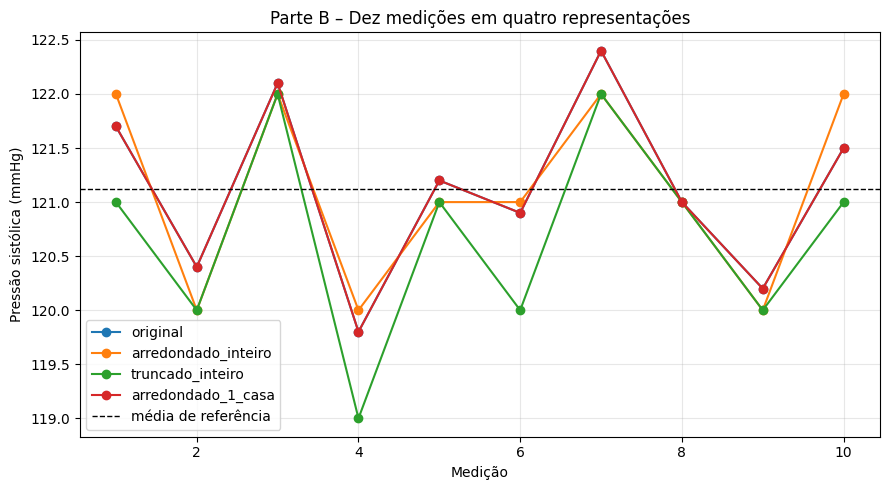

In [6]:
# Gráfico 1: as dez medições, quatro séries
fig, ax = plt.subplots(figsize=(9, 5))
x_idx = np.arange(1, 11)
for nome, serie in series_B.items():
    ax.plot(x_idx, serie, "o-", label=nome)
ax.axhline(media_referencia, color="k", ls="--", lw=1, label="média de referência")
ax.set_xlabel("Medição")
ax.set_ylabel("Pressão sistólica (mmHg)")
ax.set_title("Parte B – Dez medições em quatro representações")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("parteB_series.png", dpi=150)
plt.show()

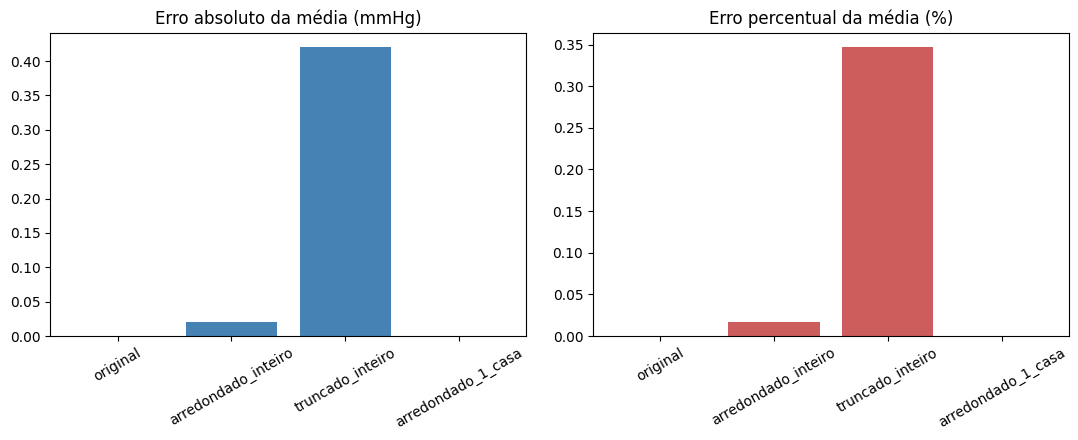

In [7]:
# Gráfico 2 e 3: barras dos erros absolutos e percentuais das médias
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].bar(df_B["serie"], df_B["Ea_media"], color="steelblue")
axs[0].set_title("Erro absoluto da média (mmHg)")
axs[0].tick_params(axis="x", rotation=30)
axs[1].bar(df_B["serie"], df_B["E%_media"], color="indianred")
axs[1].set_title("Erro percentual da média (%)")
axs[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig("parteB_barras_erros.png", dpi=150)
plt.show()

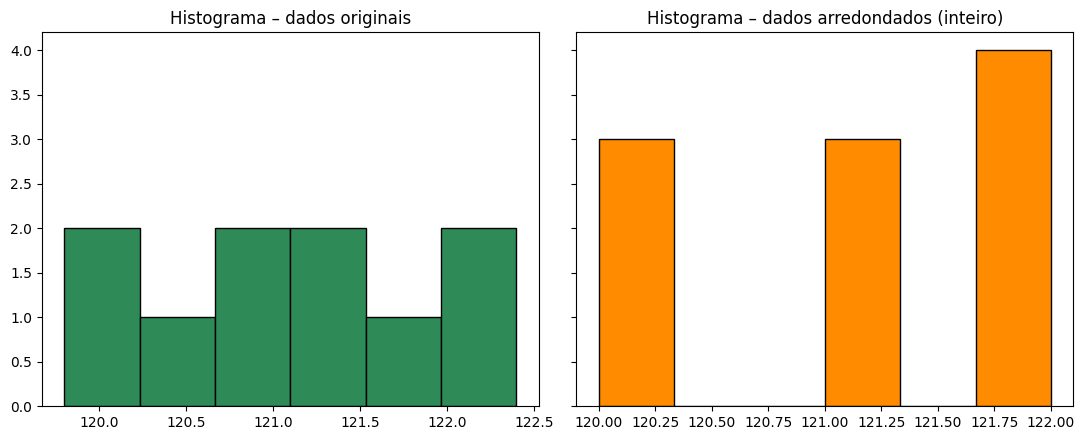

In [8]:
# Gráfico 4: histogramas dos dados originais e dos dados inteiros arredondados
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
axs[0].hist(series_B["original"], bins=6, color="seagreen", edgecolor="black")
axs[0].set_title("Histograma – dados originais")
axs[1].hist(
    series_B["arredondado_inteiro"], bins=6, color="darkorange", edgecolor="black"
)
axs[1].set_title("Histograma – dados arredondados (inteiro)")
fig.tight_layout()
fig.savefig("parteB_histogramas.png", dpi=150)
plt.show()

**Discussão:** a representação em números inteiros preserva razoavelmente
a média (erro percentual pequeno, ver `df_B`), mas reduz a variabilidade
observável: como a amplitude real dos dados é de poucas unidades de
mmHg, arredondar/truncar para inteiro faz vários valores diferentes
colapsarem no mesmo número, achatando o histograma e diminuindo o
desvio-padrão amostral em relação aos dados originais. Para esta amostra
pequena, a média é bem preservada, mas a variabilidade fina é perdida.
_(não é feita interpretação médica dos valores, apenas numérica)_

# Parte C – Vazão em um tubo de pequeno diâmetro (Hagen–Poiseuille)

$$Q = \dfrac{\pi r^4 \Delta p}{8 \mu L}$$

In [9]:
def vazao(r, L, mu, dp):
    """Vazão de Hagen-Poiseuille (unidades SI: r e L em metros, mu em Pa.s,
    dp em Pa); retorna Q em m^3/s."""
    return math.pi * r ** 4 * dp / (8 * mu * L)


# valores de referência (Parte C)
r_C_mm, L_C, mu_C, dp_C = 0.80, 0.20, 3.5e-3, 1200.0
r_C = r_C_mm * 1e-3  # m

Q_C_ref = vazao(r_C, L_C, mu_C, dp_C)
print(f"Q de referência (Parte C): {Q_C_ref:.6e} m^3/s")

Q de referência (Parte C): 2.757421e-07 m^3/s


In [10]:
# C.1 - cenários de precisão das variáveis
r_round_mm, r_trunc_mm = arredondar(r_C_mm, 1), truncar(r_C_mm, 1)
mu_round, mu_trunc = arredondar(mu_C, 3), truncar(mu_C, 3)
dp_round = round(dp_C / 100) * 100
dp_trunc = math.trunc(dp_C / 100) * 100

cenarios_C = {
    "1. todos os valores fornecidos": vazao(r_C, L_C, mu_C, dp_C),
    "2a. r arredondado (1 casa, mm)": vazao(r_round_mm * 1e-3, L_C, mu_C, dp_C),
    "2b. r truncado (1 casa, mm)": vazao(r_trunc_mm * 1e-3, L_C, mu_C, dp_C),
    "3a. mu arredondada (3 casas)": vazao(r_C, L_C, mu_round, dp_C),
    "3b. mu truncada (3 casas)": vazao(r_C, L_C, mu_trunc, dp_C),
    "4a. dp arredondada (centena)": vazao(r_C, L_C, mu_C, dp_round),
    "4b. dp truncada (centena)": vazao(r_C, L_C, mu_C, dp_trunc),
    "5a. todas arredondadas": vazao(r_round_mm * 1e-3, L_C, mu_round, dp_round),
    "5b. todas truncadas": vazao(r_trunc_mm * 1e-3, L_C, mu_trunc, dp_trunc),
}

linhas_C1 = []
for nome, Q in cenarios_C.items():
    ea, er, ep = calcular_erros(Q_C_ref, Q)
    linhas_C1.append({"cenario": nome, "Q": Q, "Ea": ea, "Er": er, "E%": ep})
df_C1 = pd.DataFrame(linhas_C1)
display(df_C1)
df_C1.to_csv("parteC1_tabela.csv", index=False)

,cenario,Q,Ea,Er,E%
0,1. todos os valores fornecidos,0.00000028,0.00000000,0.00000000,0.00000000
1,"2a. r arredondado (1 casa, mm)",0.00000028,0.00000000,0.00000000,0.00000000
2,"2b. r truncado (1 casa, mm)",0.00000028,0.00000000,0.00000000,0.00000000
3,3a. mu arredondada (3 casas),0.00000024,0.00000003,0.12500000,12.50000000
4,3b. mu truncada (3 casas),0.00000032,0.00000005,0.16666667,16.66666667
5,4a. dp arredondada (centena),0.00000028,0.00000000,0.00000000,0.00000000
6,4b. dp truncada (centena),0.00000028,0.00000000,0.00000000,0.00000000
7,5a. todas arredondadas,0.00000024,0.00000003,0.12500000,12.50000000
8,5b. todas truncadas,0.00000032,0.00000005,0.16666667,16.66666667


In [11]:
# C.2 - sensibilidade: varia r de 0.70 a 0.90 mm
r_mm_vals = np.arange(0.70, 0.901, 0.01)
regs = []
for r_mm in r_mm_vals:
    r_m = r_mm * 1e-3
    r_round = arredondar(r_mm, 1) * 1e-3
    r_trunc = truncar(r_mm, 1) * 1e-3
    Q_ref = vazao(r_m, L_C, mu_C, dp_C)
    Q_round = vazao(r_round, L_C, mu_C, dp_C)
    Q_trunc = vazao(r_trunc, L_C, mu_C, dp_C)
    ea_r, er_r, ep_r = calcular_erros(Q_ref, Q_round)
    ea_t, er_t, ep_t = calcular_erros(Q_ref, Q_trunc)
    regs.append(
        dict(
            r_mm=r_mm,
            Q_ref=Q_ref,
            Q_round=Q_round,
            Q_trunc=Q_trunc,
            Ea_round=ea_r,
            Er_round=er_r,
            Ep_round=ep_r,
            Ea_trunc=ea_t,
            Er_trunc=er_t,
            Ep_trunc=ep_t,
        )
    )
df_C2 = pd.DataFrame(regs)
display(df_C2.head())
df_C2.to_csv("parteC2_tabela.csv", index=False)

,r_mm,Q_ref,Q_round,Q_trunc,Ea_round,Er_round,Ep_round,Ea_trunc,Er_trunc,Ep_trunc
0,0.70000000,0.00000016,0.00000016,0.00000016,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
1,0.71000000,0.00000017,0.00000016,0.00000016,0.00000001,0.05515892,5.51589247,0.00000001,0.05515892,5.51589247
2,0.72000000,0.00000018,0.00000016,0.00000016,0.00000002,0.10656662,10.65666200,0.00000002,0.10656662,10.65666200
3,0.73000000,0.00000019,0.00000016,0.00000016,0.00000003,0.15452510,15.45250989,0.00000003,0.15452510,15.45250989
4,0.74000000,0.00000020,0.00000016,0.00000016,0.00000004,0.19930838,19.93083839,0.00000004,0.19930838,19.93083839


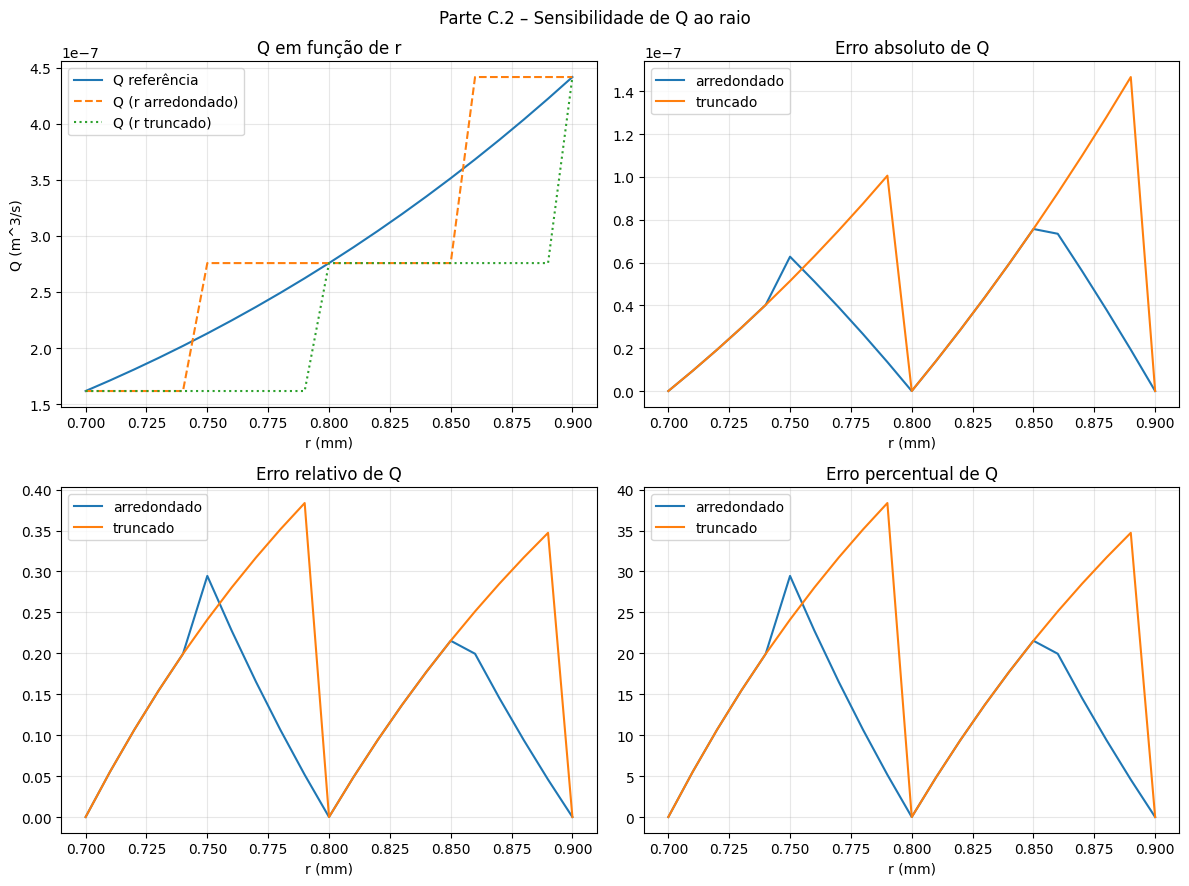

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs[0, 0].plot(df_C2.r_mm, df_C2.Q_ref, label="Q referência")
axs[0, 0].plot(df_C2.r_mm, df_C2.Q_round, "--", label="Q (r arredondado)")
axs[0, 0].plot(df_C2.r_mm, df_C2.Q_trunc, ":", label="Q (r truncado)")
axs[0, 0].set_title("Q em função de r")
axs[0, 0].set_xlabel("r (mm)")
axs[0, 0].set_ylabel("Q (m^3/s)")
axs[0, 0].legend()

axs[0, 1].plot(df_C2.r_mm, df_C2.Ea_round, label="arredondado")
axs[0, 1].plot(df_C2.r_mm, df_C2.Ea_trunc, label="truncado")
axs[0, 1].set_title("Erro absoluto de Q")
axs[0, 1].set_xlabel("r (mm)")
axs[0, 1].legend()

axs[1, 0].plot(df_C2.r_mm, df_C2.Er_round, label="arredondado")
axs[1, 0].plot(df_C2.r_mm, df_C2.Er_trunc, label="truncado")
axs[1, 0].set_title("Erro relativo de Q")
axs[1, 0].set_xlabel("r (mm)")
axs[1, 0].legend()

axs[1, 1].plot(df_C2.r_mm, df_C2.Ep_round, label="arredondado")
axs[1, 1].plot(df_C2.r_mm, df_C2.Ep_trunc, label="truncado")
axs[1, 1].set_title("Erro percentual de Q")
axs[1, 1].set_xlabel("r (mm)")
axs[1, 1].legend()

for ax in axs.flat:
    ax.grid(alpha=0.3)
fig.suptitle("Parte C.2 – Sensibilidade de Q ao raio")
fig.tight_layout()
fig.savefig("parteC2_sensibilidade.png", dpi=150)
plt.show()

**Por que o erro é amplificado?** Como $Q \propto r^4$, um erro relativo
$\delta$ no raio se propaga aproximadamente como $4\delta$ na vazão
(derivada logarítmica: $d\ln Q/d\ln r = 4$). Isso é visível nos gráficos
acima: mesmo pequenos desvios de arredondamento/truncamento do raio geram
erros proporcionalmente maiores em Q, por causa do expoente 4.

# Parte D – Escoamento em um nanocateter

In [13]:
r_D, L_D, mu_D, dp_D = 50e-9, 10e-6, 3.5e-3, 5000.0  # SI
Q_D_ref = vazao(r_D, L_D, mu_D, dp_D)
print(f"Q de referência (nanocateter, r=50nm): {Q_D_ref:.6e} m^3/s")

Q de referência (nanocateter, r=50nm): 3.506242e-19 m^3/s


## D.1 – Erro geométrico

In [14]:
delta_r_nm = np.arange(0.1, 5.01, 0.1)
regs_D1 = []
for dr_nm in delta_r_nm:
    dr_m = dr_nm * 1e-9
    r_minus, r_plus = r_D - dr_m, r_D + dr_m
    Q_minus = vazao(r_minus, L_D, mu_D, dp_D)
    Q_plus = vazao(r_plus, L_D, mu_D, dp_D)
    Q_r = Q_D_ref

    ea_minus = abs(Q_r - Q_minus)
    ea_plus = abs(Q_r - Q_plus)
    ea_max = max(ea_minus, ea_plus)
    er_max = ea_max / Q_r
    ep_max = 100 * er_max

    aprox_linear = 4 * (dr_m / r_D)  # dQ/Q approx

    regs_D1.append(
        dict(
            delta_r_nm=dr_nm,
            Q_minus=Q_minus,
            Q_r=Q_r,
            Q_plus=Q_plus,
            Ea_max=ea_max,
            Er_max=er_max,
            Ep_max=ep_max,
            aprox_linear_Er=aprox_linear,
        )
    )
df_D1 = pd.DataFrame(regs_D1)
display(df_D1.head())
df_D1.to_csv("parteD1_tabela.csv", index=False)

,delta_r_nm,Q_minus,Q_r,Q_plus,Ea_max,Er_max,Ep_max,aprox_linear_Er
0,0.10000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00802403,0.80240320,0.00800000
1,0.20000000,0.00000000,0.00000000,0.00000000,0.00000000,0.01609626,1.60962563,0.01600000
2,0.30000000,0.00000000,0.00000000,0.00000000,0.00000000,0.02421687,2.42168653,0.02400000
3,0.40000000,0.00000000,0.00000000,0.00000000,0.00000000,0.03238605,3.23860521,0.03200000
4,0.50000000,0.00000000,0.00000000,0.00000000,0.00000000,0.04060401,4.06040100,0.04000000


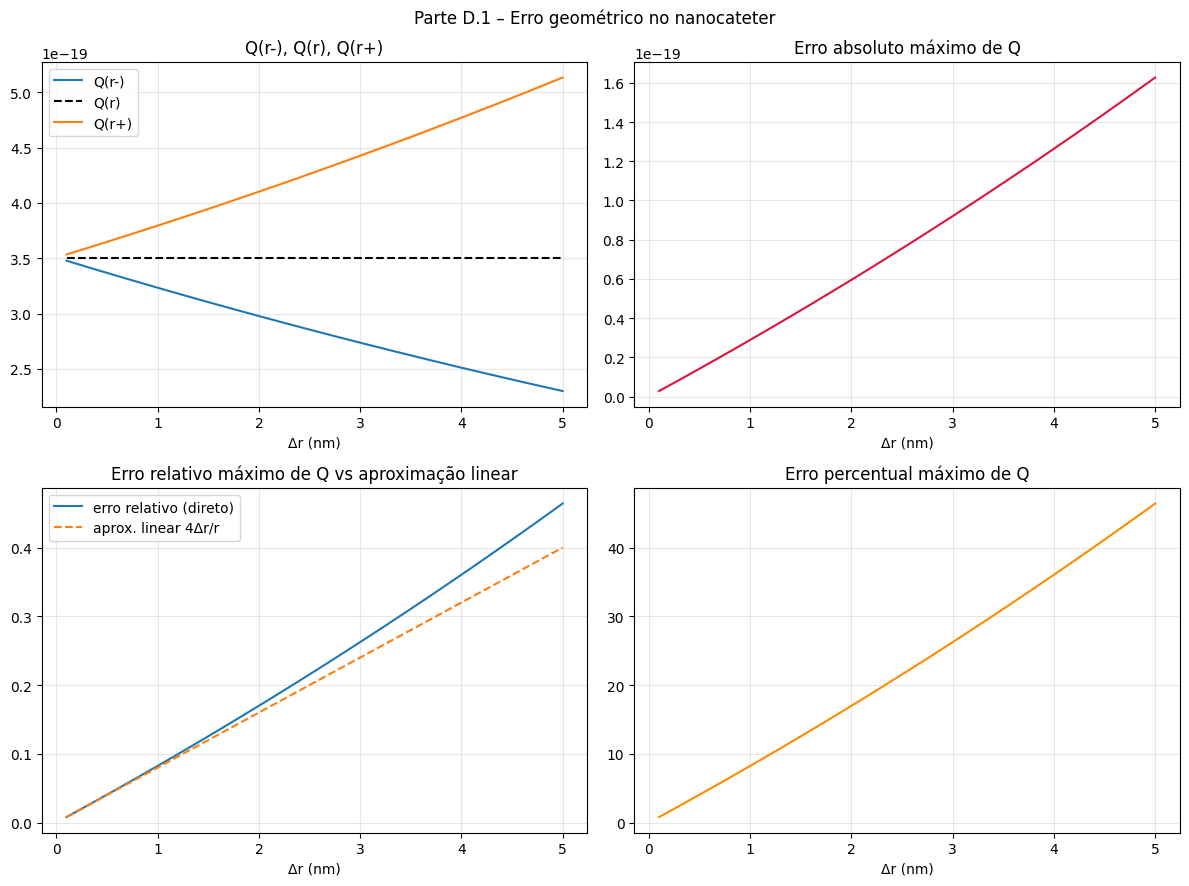

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs[0, 0].plot(df_D1.delta_r_nm, df_D1.Q_minus, label="Q(r-)")
axs[0, 0].plot(df_D1.delta_r_nm, df_D1.Q_r, "k--", label="Q(r)")
axs[0, 0].plot(df_D1.delta_r_nm, df_D1.Q_plus, label="Q(r+)")
axs[0, 0].set_title("Q(r-), Q(r), Q(r+)")
axs[0, 0].set_xlabel("Δr (nm)")
axs[0, 0].legend()

axs[0, 1].plot(df_D1.delta_r_nm, df_D1.Ea_max, color="crimson")
axs[0, 1].set_title("Erro absoluto máximo de Q")
axs[0, 1].set_xlabel("Δr (nm)")

axs[1, 0].plot(df_D1.delta_r_nm, df_D1.Er_max, label="erro relativo (direto)")
axs[1, 0].plot(
    df_D1.delta_r_nm, df_D1.aprox_linear_Er, "--", label="aprox. linear 4Δr/r"
)
axs[1, 0].set_title("Erro relativo máximo de Q vs aproximação linear")
axs[1, 0].set_xlabel("Δr (nm)")
axs[1, 0].legend()

axs[1, 1].plot(df_D1.delta_r_nm, df_D1.Ep_max, color="darkorange")
axs[1, 1].set_title("Erro percentual máximo de Q")
axs[1, 1].set_xlabel("Δr (nm)")

for ax in axs.flat:
    ax.grid(alpha=0.3)
fig.suptitle("Parte D.1 – Erro geométrico no nanocateter")
fig.tight_layout()
fig.savefig("parteD1_erro_geometrico.png", dpi=150)
plt.show()

A aproximação linear $\Delta Q/Q \approx 4\Delta r/r$ acompanha bem o erro
relativo real para Δr pequeno frente a r=50 nm, e a diferença entre a
curva "direta" e a aproximação cresce à medida que Δr aumenta (a
aproximação linear é a primeira derivada; termos de ordem superior de
$(1+\Delta r/r)^4$ passam a importar).

## D.2 – Precisão computacional (float32 vs float64)

In [16]:
def vazao_precisao(r, L, mu, dp, dtype):
    r, L, mu, dp = dtype(r), dtype(L), dtype(mu), dtype(dp)
    pi = dtype(np.pi)
    quatro, oito = dtype(4), dtype(8)
    return pi * r ** quatro * dp / (oito * mu * L)


resultados_precisao = {}
for dtype, nome in [(np.float32, "float32"), (np.float64, "float64")]:
    r_t = dtype(r_D)
    r4 = r_t ** dtype(4)
    Q_t = vazao_precisao(r_D, L_D, mu_D, dp_D, dtype)
    eps = np.finfo(dtype).eps
    resultados_precisao[nome] = {"r4": r4, "Q": Q_t, "eps": eps}

Q32 = resultados_precisao["float32"]["Q"]
Q64 = resultados_precisao["float64"]["Q"]
diff_abs = abs(float(Q64) - float(Q32))
diff_rel = diff_abs / abs(float(Q64))

df_precisao = pd.DataFrame(resultados_precisao).T
df_precisao["diff_abs_vs_float64"] = [diff_abs, 0.0]
df_precisao["diff_rel_vs_float64"] = [diff_rel, 0.0]
display(df_precisao)
df_precisao.to_csv("parteD2_precisao.csv")

print(f"Diferença absoluta Q64-Q32: {diff_abs:.6e}")
print(f"Diferença relativa (Q64-Q32)/Q64: {diff_rel:.6e}")

,r4,Q,eps,diff_abs_vs_float64,diff_rel_vs_float64
float32,0.00000000,0.00000000,0.00000012,0.00000000,0.00000015
float64,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000


Diferença absoluta Q64-Q32: 5.228628e-26
Diferença relativa (Q64-Q32)/Q64: 1.491234e-07


In [17]:
# Comparação de delta1 (direto) e delta2 (expandido) para dr/r decrescente
razoes = np.logspace(-1, -8, 20)  # dr/r de 0.1 até 1e-8
linhas_delta = []
for dtype, nome in [(np.float64, "float64"), (np.float32, "float32")]:
    r_t = dtype(r_D)
    Q_r = vazao_precisao(r_D, L_D, mu_D, dp_D, dtype)
    for razao in razoes:
        dr = dtype(razao) * r_t
        Q_dr = vazao_precisao(r_t + dr, L_D, mu_D, dp_D, dtype)
        delta1 = (Q_dr - Q_r) / Q_r
        delta2 = (dtype(1) + dtype(razao)) ** dtype(4) - dtype(1)
        linhas_delta.append(
            dict(
                precisao=nome,
                dr_sobre_r=razao,
                delta1_direto=float(delta1),
                delta2_expandido=float(delta2),
                diferenca=float(delta1) - float(delta2),
            )
        )
df_delta = pd.DataFrame(linhas_delta)
display(df_delta)
df_delta.to_csv("parteD2_cancelamento.csv", index=False)

,precisao,dr_sobre_r,delta1_direto,delta2_expandido,diferenca
0,float64,0.10000000,0.46410000,0.46410000,-0.00000000
1,float64,0.04281332,0.18256844,0.18256844,-0.00000000
2,float64,0.01832981,0.07535987,0.07535987,-0.00000000
3,float64,0.00784760,0.03176184,0.03176184,-0.00000000
4,float64,0.00335982,0.01350716,0.01350716,-0.00000000
5,float64,0.00143845,0.00576623,0.00576623,0.00000000
6,float64,0.00061585,0.00246567,0.00246567,-0.00000000
7,float64,0.00026367,0.00105508,0.00105508,-0.00000000
8,float64,0.00011288,0.00045161,0.00045161,0.00000000
9,float64,0.00004833,0.00019333,0.00019333,0.00000000


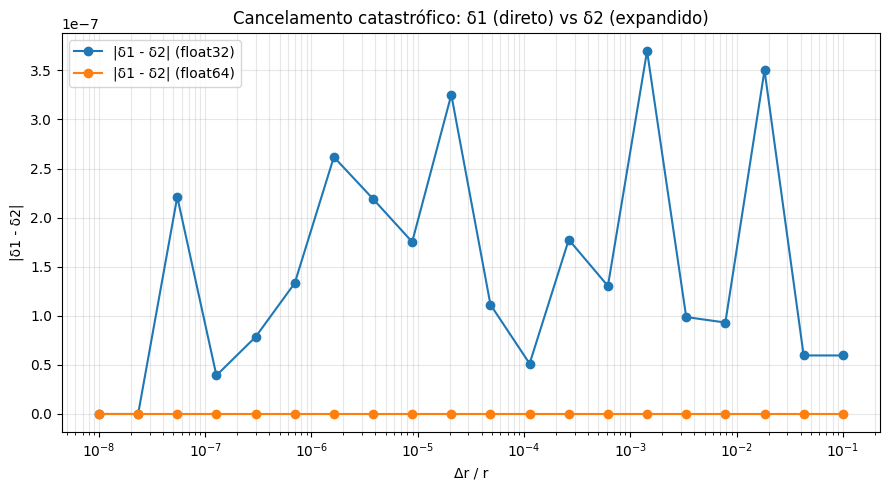

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
for nome, grp in df_delta.groupby("precisao"):
    ax.semilogx(
        grp.dr_sobre_r, np.abs(grp.diferenca), "o-", label=f"|δ1 - δ2| ({nome})"
    )
ax.set_xlabel("Δr / r")
ax.set_ylabel("|δ1 - δ2|")
ax.set_title("Cancelamento catastrófico: δ1 (direto) vs δ2 (expandido)")
ax.legend()
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
fig.savefig("parteD2_delta_comparacao.png", dpi=150)
plt.show()

Para razões $\Delta r / r$ pequenas, $\delta_1$ (calculado como diferença
direta $Q(r+\Delta r)/Q(r) - 1$) sofre **perda de significância por
cancelamento catastrófico**, pois subtrai dois números muito próximos em
ponto flutuante. Já $\delta_2 = (1+\Delta r/r)^4 - 1$ evita subtrair
diretamente valores de Q e é numericamente mais estável. Em `float32`
esse efeito aparece com razões `dr/r` bem maiores do que em `float64`,
pois o épsilon de máquina de `float32` é muito maior (ver `df_precisao`).

## D.3 – Fenômeno físico

Ao reduzir a escala do canal de milímetros (Parte C) para nanômetros
(Parte D), a razão superfície/volume do escoamento aumenta drasticamente
(a área da parede cresce com $r$, enquanto o volume cresce com $r^2$ na
seção transversal, então a razão superfície/volume escala como $1/r$).
Isso significa que, em um nanocateter, uma fração muito maior do fluido
está em contato direto com a parede do canal, tornando os efeitos
viscosos e de interação com a parede (atrito, camada limite, possíveis
efeitos de deslizamento ou de dupla camada elétrica em escala
nanométrica) proporcionalmente muito mais importantes do que em tubos
maiores — mesmo que a equação de Hagen–Poiseuille continue sendo usada
como aproximação didática. Um resultado numérico com muitas casas
decimais pode ser aritmeticamente exato e, ainda assim, fisicamente
inadequado nessa escala: precisão aritmética e validade do modelo físico
são conceitos diferentes.

# Parte E – Síntese visual (quadro único, PNG ≥ 1600×1000)

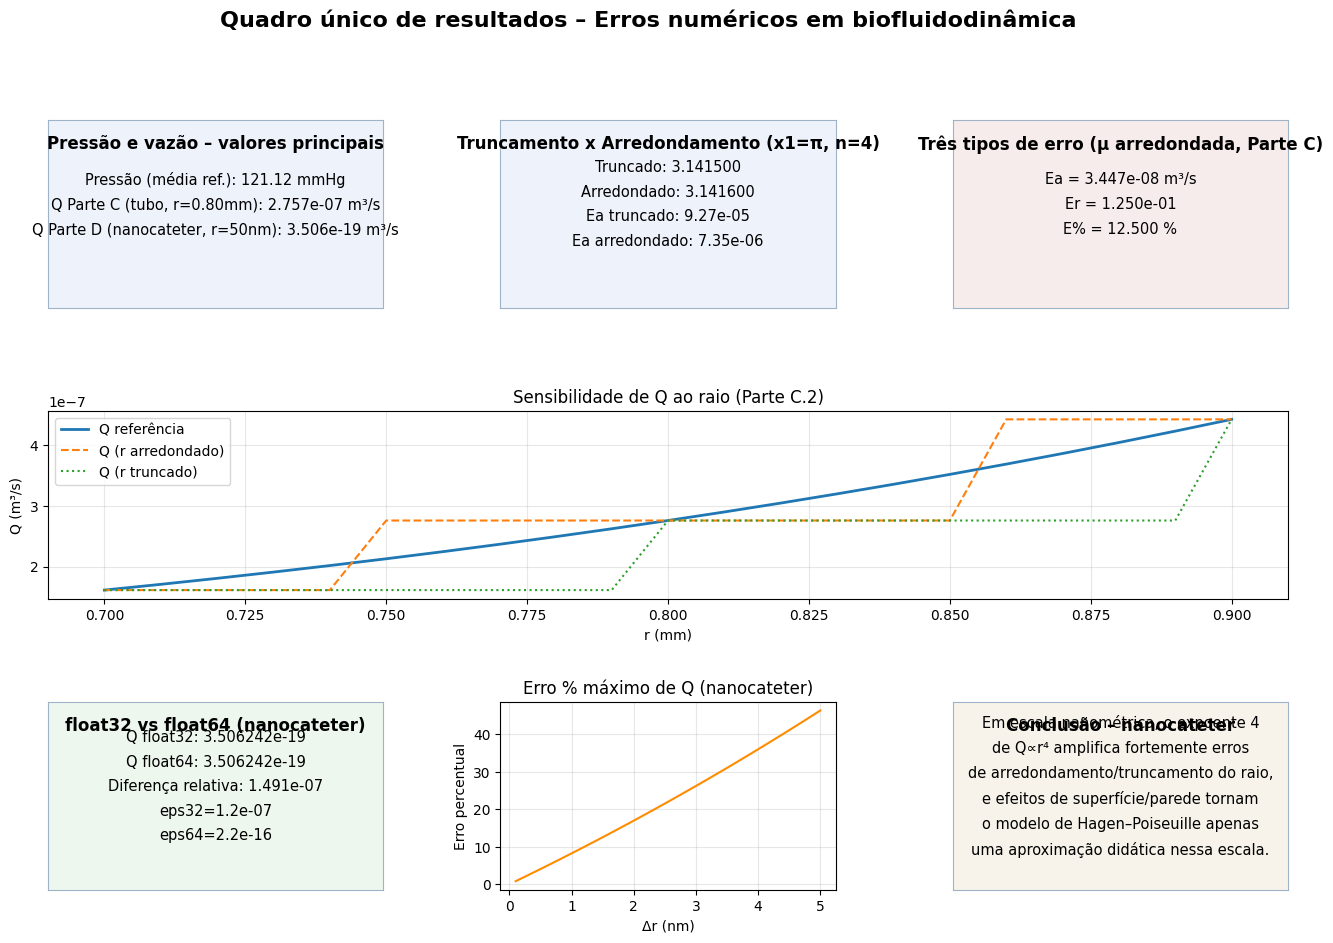

PNG salvo: quadro_resultados.png (1600x1000 px)


In [19]:
fig = plt.figure(figsize=(16, 10), dpi=100)  # 1600x1000 px
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)


def cartao(ax, titulo, linhas, cor="#eef3fb"):
    ax.set_facecolor(cor)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#9fb3c8")
    ax.text(0.5, 0.92, titulo, ha="center", va="top", fontsize=12, fontweight="bold")
    ax.text(
        0.5,
        0.55,
        "\n".join(linhas),
        ha="center",
        va="center",
        fontsize=10.5,
        linespacing=1.8,
    )


# Cartão 1: valores principais de pressão e vazão
ax1 = fig.add_subplot(gs[0, 0])
cartao(
    ax1,
    "Pressão e vazão – valores principais",
    [
        f"Pressão (média ref.): {media_referencia:.2f} mmHg",
        f"Q Parte C (tubo, r=0.80mm): {Q_C_ref:.3e} m³/s",
        f"Q Parte D (nanocateter, r=50nm): {Q_D_ref:.3e} m³/s",
    ],
)

# Cartão 2: truncamento x arredondamento (Parte A, x1)
ax2 = fig.add_subplot(gs[0, 1])
sub_x1 = df_A[df_A.variavel == "x1"]
cartao(
    ax2,
    "Truncamento x Arredondamento (x1=π, n=4)",
    [
        f"Truncado: {sub_x1[sub_x1.n_casas==4].truncado.values[0]:.6f}",
        f"Arredondado: {sub_x1[sub_x1.n_casas==4].arredondado.values[0]:.6f}",
        f"Ea truncado: {sub_x1[sub_x1.n_casas==4].Ea_trunc.values[0]:.2e}",
        f"Ea arredondado: {sub_x1[sub_x1.n_casas==4].Ea_arred.values[0]:.2e}",
    ],
)

# Cartão 3: os três tipos de erro (exemplo Parte C.1, cenário 3a)
ax3 = fig.add_subplot(gs[0, 2])
linha_ex = df_C1[df_C1.cenario.str.startswith("3a")].iloc[0]
cartao(
    ax3,
    "Três tipos de erro (μ arredondada, Parte C)",
    [
        f"Ea = {linha_ex.Ea:.3e} m³/s",
        f"Er = {linha_ex.Er:.3e}",
        f"E% = {linha_ex['E%']:.3f} %",
    ],
    cor="#f7ecec",
)

# Gráfico 4: sensibilidade de Q ao raio (ocupa 1 linha inteira)
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(df_C2.r_mm, df_C2.Q_ref, label="Q referência", lw=2)
ax4.plot(df_C2.r_mm, df_C2.Q_round, "--", label="Q (r arredondado)")
ax4.plot(df_C2.r_mm, df_C2.Q_trunc, ":", label="Q (r truncado)")
ax4.set_title("Sensibilidade de Q ao raio (Parte C.2)")
ax4.set_xlabel("r (mm)")
ax4.set_ylabel("Q (m³/s)")
ax4.legend()
ax4.grid(alpha=0.3)

# Cartão 5: float32 x float64
ax5 = fig.add_subplot(gs[2, 0])
cartao(
    ax5,
    "float32 vs float64 (nanocateter)",
    [
        f"Q float32: {Q32:.6e}",
        f"Q float64: {Q64:.6e}",
        f"Diferença relativa: {diff_rel:.3e}",
        f"eps32={np.finfo(np.float32).eps:.1e}",
        f"eps64={np.finfo(np.float64).eps:.1e}",
    ],
    cor="#eef7ee",
)

# Gráfico 6: erro percentual máximo de Q no nanocateter
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(df_D1.delta_r_nm, df_D1.Ep_max, color="darkorange")
ax6.set_title("Erro % máximo de Q (nanocateter)")
ax6.set_xlabel("Δr (nm)")
ax6.set_ylabel("Erro percentual")
ax6.grid(alpha=0.3)

# Cartão 7: conclusão
ax7 = fig.add_subplot(gs[2, 2])
cartao(
    ax7,
    "Conclusão – nanocateter",
    [
        "Em escala nanométrica, o expoente 4",
        "de Q∝r⁴ amplifica fortemente erros",
        "de arredondamento/truncamento do raio,",
        "e efeitos de superfície/parede tornam",
        "o modelo de Hagen–Poiseuille apenas",
        "uma aproximação didática nessa escala.",
    ],
    cor="#f7f3ea",
)

fig.suptitle(
    "Quadro único de resultados – Erros numéricos em biofluidodinâmica",
    fontsize=16,
    fontweight="bold",
    y=0.99,
)
fig.savefig("quadro_resultados.png", dpi=100)  # 16*100 x 10*100 = 1600x1000
plt.show()
print("PNG salvo: quadro_resultados.png (1600x1000 px)")

# Parte 8 – GIF demonstrativo (nanocateter, r de 45 a 55 nm)

GIF salvo: nanocateter.gif (41 quadros)


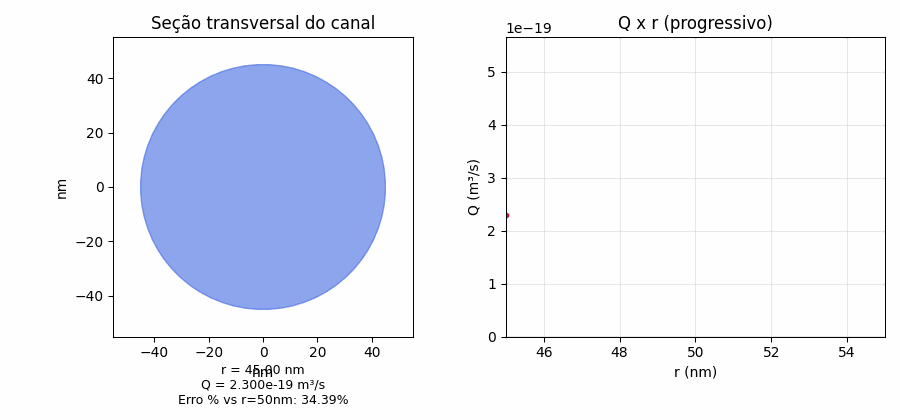

In [20]:
raios_gif_nm = np.linspace(45, 55, 41)  # 41 quadros (dentro de 30-60)
r_base_nm = 50.0
Q_base = vazao(r_base_nm * 1e-9, L_D, mu_D, dp_D)

frames = []
Qs_construidos = []
raios_construidos = []

for r_nm in raios_gif_nm:
    r_m = r_nm * 1e-9
    Q_atual = vazao(r_m, L_D, mu_D, dp_D)
    erro_pct = 100 * abs(Q_atual - Q_base) / Q_base

    raios_construidos.append(r_nm)
    Qs_construidos.append(Q_atual)

    fig_gif, (axL, axR) = plt.subplots(1, 2, figsize=(9, 4.2))

    # Painel esquerdo: seção transversal do canal
    raio_max_escala = 55
    circ = plt.Circle((0, 0), r_nm, color="royalblue", alpha=0.6)
    axL.add_patch(circ)
    axL.set_xlim(-raio_max_escala, raio_max_escala)
    axL.set_ylim(-raio_max_escala, raio_max_escala)
    axL.set_aspect("equal")
    axL.set_title("Seção transversal do canal")
    axL.set_xlabel("nm")
    axL.set_ylabel("nm")
    axL.text(
        0,
        -raio_max_escala * 1.18,
        f"r = {r_nm:5.2f} nm\nQ = {Q_atual:.3e} m³/s\nErro % vs r=50nm: {erro_pct:5.2f}%",
        ha="center",
        va="top",
        fontsize=9,
    )

    # Painel direito: curva Q x r sendo construída progressivamente
    axR.plot(raios_construidos, Qs_construidos, "o-", color="crimson", ms=3)
    axR.set_xlim(45, 55)
    axR.set_ylim(min(vazao(45e-9, L_D, mu_D, dp_D), 0) * 0.9,
                 vazao(55e-9, L_D, mu_D, dp_D) * 1.1)
    axR.set_title("Q x r (progressivo)")
    axR.set_xlabel("r (nm)")
    axR.set_ylabel("Q (m³/s)")
    axR.grid(alpha=0.3)

    fig_gif.tight_layout()

    buf = io.BytesIO()
    fig_gif.savefig(buf, format="png", dpi=100)
    plt.close(fig_gif)
    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave("nanocateter.gif", frames, fps=6, loop=0)
print(f"GIF salvo: nanocateter.gif ({len(frames)} quadros)")
display(Image(filename="nanocateter.gif"))

# Conclusão geral

Ao longo desta atividade observamos que: (1) arredondar nunca é pior do
que truncar em termos de erro absoluto; (2) mesmo em uma amostra pequena
de pressão arterial, representações inteiras preservam bem a média mas
apagam a variabilidade fina dos dados; (3) como a vazão de
Hagen–Poiseuille depende de $r^4$, pequenos erros de arredondamento ou
truncamento no raio são amplificados cerca de 4 vezes na vazão, efeito
que se torna crítico em escala nanométrica; e (4) a escolha de como
calcular uma diferença pequena (forma direta vs. forma expandida
algebricamente) e a precisão de ponto flutuante utilizada (`float32` vs
`float64`) podem introduzir erros de cancelamento que nada têm a ver com
o fenômeno físico em si — reforçando que precisão numérica e validade do
modelo físico são questões distintas, especialmente relevante ao
extrapolar um modelo macroscópico (Hagen–Poiseuille) para a escala de um
nanocateter.